# PRODUCTION: DTU ORBIT Meta Data

## Cleaning the Metadata from DTU ORBIT

In [32]:
# ==== Imports ====
import pandas as pd
from matplotlib.pylab import power
import json
import re
import pandas as pd


# ==== Loading the data ====


df_orbit = pd.read_csv('../Data/Orbit_meta/dtu_orbit_persons_raw.csv')
pd.set_option("display.max_colwidth", None)  # Show full text in cells

# making everything in the dataset lowercase
df_orbit = df_orbit.map(lambda x: x.lower() if isinstance(x, str) else x)

# Professor, National Institute of Aquatic Resources
display(df_orbit.head(2))
print("Number of rows in raw dataset: ", len(df_orbit))


# ==== Split affiliations ==== 


# Split affiliations into:
# 1) professional_title (before first comma) 
# 2) dtu_department (after first comma)

parts = df_orbit["affiliations"].astype("string").str.split(",", n=1, expand=True)

df_orbit["professional_title"] = parts[0].str.strip()
df_orbit["dtu_department"] = parts[1].str.strip()

# If no comma existed, keep department as missing value (already NaN/<NA>)
df_orbit["dtu_department"] = df_orbit["dtu_department"].fillna(pd.NA)

# Quick check
display(df_orbit[["affiliations", "professional_title", "dtu_department"]].head(10))
print("Rows with missing title:", df_orbit["professional_title"].isna().sum())
print("Rows with missing department:", df_orbit["dtu_department"].isna().sum())


# ==== Keeping titles allowed to supervise ====


# Job categories:
# Eng: assistant professor, associate professor, professor, researcher, senior researcher, senior adviser
# Dan: adjunkt, lektor, docent, ingeniørdocent, professor, forsker, seniorforsker, seniorrådgiver

SUPERVISOR_TITLES = {
                    'adjunkt', 'lektor', 'docent', 'ingeniørdocent', 'professor', 'forsker', 'seniorforsker', 'seniorrådgiver',
                    'assistant professor', 'associate professor', 'professor', 'researcher', 'senior researcher', 'sr researcher', 
                    'senior adviser', 'senior advisor'
                    }
SUPERVISOR_ADDITIONALS = {'senior scientist', 'deputy director / professor', 'professor and head of section', 
                          'assistant professor (tenure track)', 'researcher (tenure track)', 'senior researcher & group leader',
                          'visiting professor', 'visiting senior researcher', 
                          'associate professor department of neurology rigshospitalet', 'research associate', 'assistent professor',
                          'professor and head of measurement and instrumentation', 'professor head of section indoor environment',
                          'adjunct professor', 'affiliated associate professor', 'honorary professor', 'research director and professor',
                          'professor department of neurology copenhagen university hospital', 'adjungeret professor', 
                          'associate professor and head of electromagnetic systems', 'associate professor department of neurology rigshospitalet',
                          'professor and head of measurement and instrumentation', 'professor and head of section',
                          'professor department of neurology copenhagen university hospital', 'professor director bright biofoundry',
                          'professor head of section indoor environment', 'professor of finance', 'senior scientific officer'
                        }
COSUPERVISOR_TITLES = {'researcher', 'post.doc', 'phd student', 'external associate professor', 'forsker', 'post.doc', 'ph.d. student', 
                       'ph.d. fellow', 'ph.d. stipendiat', 'ph.d. student', 'postdoc', 'post doc', 'post-doctoral researcher',
                        'industrial phd', 'industrial phd energinet', 'industrial phd konstant net a/s', 'industrial phd lm wind power', 
                        'industrial phd rambøll','industrial phd siemens gamesa','industrial phd student','industrial phd thil','industrial phd ørsted',
                        'industrial postdoc', 'lecturer', 'phd independent student', 'phd student', 'postdoc', 
                        'postdoctoral researcher in developing process simulations and estimating sustainability performance', 'scientist',
                        'senior lecturer', 'senior researcher', 'senior researcher & group leader', 'tidl. ph.d.-studerende',
                        'visiting phd student', 'visiting postdoc', 'visiting researcher', 'visiting scientist', 'visiting senior researcher', 
                        'visiting professor', 'research associate', 'adviser', 'advisor', 'advisor cfb 2.0 phase out', 'advisor on freshwater fisheries management'
                       }


# Normalize title column before filtering (safe)
df_orbit["professional_title"] = df_orbit["professional_title"].astype("string").str.strip()

before = len(df_orbit)

sorting = input("Sort by (1) supervisor titles only, (2) supervisor + additional titles, (3) supervisor + additional + co-supervisor titles: ")
print(f"Filtering dataset with sorting option... {sorting}")
if sorting == "1":
    df_orbit_cut = df_orbit[
                            df_orbit["professional_title"].isin(SUPERVISOR_TITLES)
                            ].copy()
elif sorting == "2":
    df_orbit_cut = df_orbit[
                            df_orbit["professional_title"].isin(SUPERVISOR_TITLES) | 
                            df_orbit["professional_title"].isin(SUPERVISOR_ADDITIONALS)
                            ].copy()
elif sorting == "3":
    df_orbit_cut = df_orbit[
                            df_orbit["professional_title"].isin(SUPERVISOR_TITLES) | 
                            df_orbit["professional_title"].isin(SUPERVISOR_ADDITIONALS) | 
                            df_orbit["professional_title"].isin(COSUPERVISOR_TITLES)
                            ].copy()

after = len(df_orbit_cut)

print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")


# ==== Mapping all titles to main titles ====


# Combined Mapping of all Titles
# Priority is handled by checking longer strings first
CORE_MAPPING = {
    # Postdocs & Researchers
    'post-doctoral researcher': 'postdoc',
    'postdoctoral researcher': 'postdoc',
    'visiting senior researcher': 'senior researcher',
    'visiting researcher': 'researcher',
    'senior researcher': 'senior researcher',
    'seniorforsker': 'senior researcher',
    'sr researcher': 'senior researcher',
    'visiting postdoc': 'postdoc',
    'industrial postdoc': 'industrial postdoc',
    'post.doc': 'postdoc',
    'post doc': 'postdoc',
    'postdoc': 'postdoc',
    'research associate': 'research associate',
    'researcher': 'researcher',
    'forsker': 'researcher',
    
    # PhD Titles (Danish & English)
    'industrial phd': 'industrial phd',
    'ph.d. stipendiat': 'phd student',
    'ph.d. fellow': 'phd student',
    'ph.d. student': 'phd student',
    'phd independent student': 'phd student',
    'visiting phd student': 'phd student',
    'tidl. ph.d.-studerende': 'phd student',
    'phd student': 'phd student',
    
    # Professors & Lecturers
    'external associate professor': 'associate professor',
    'associate professor': 'associate professor',
    'assistant professor': 'assistant professor',
    'assistent professor': 'assistant professor',
    'adjungeret professor': 'assistant professor',
    'adjunct professor': 'assistant professor',
    'honorary professor': 'professor',
    'visiting professor': 'professor',
    'adjunkt': 'assistant professor',
    'lektor': 'associate professor',
    'senior lecturer': 'senior lecturer',
    'lecturer': 'lecturer',
    'professor': 'professor',
    'docent': 'professor',
    
    # Scientists & Staff
    'visiting scientist': 'scientist',
    'senior scientist': 'senior scientist',
    'scientist': 'scientist',
    'senior scientific officer': 'senior scientific officer',
    
    # Advisors
    'seniorrådgiver': 'senior advisor',
    'senior adviser': 'senior advisor',
    'senior advisor': 'senior advisor',
    'advisor': 'advisor',
    'adviser': 'advisor'
}

def map_titles(text):
    if pd.isna(text):
        return None
    
    text_lower = str(text).lower()
    
    # We sort keys by length descending so "industrial phd" matches before "phd"
    sorted_keys = sorted(CORE_MAPPING.keys(), key=len, reverse=True)
    
    for keyword in sorted_keys:
        if keyword in text_lower:
            return CORE_MAPPING[keyword]
            
    return None # or "Unclassified"

# --- Usage ---
# Create the new column
df_orbit_cut['title_match'] = df_orbit_cut['professional_title'].apply(map_titles)

display(df_orbit_cut[['professional_title', 'title_match']].head(10))


# ==== Displaying the titles in the dataset ====


print("The titles in this set is:", df_orbit_cut["title_match"].unique())


# ==== Splitting dtu_department ====


# Split dtu_department into:
# 1) department (before first semicomma)
# 2) section (after first semicomma)
parts = df_orbit_cut["dtu_department"].astype("string").str.split(";", n=1, expand=True)

df_orbit_cut["department"] = parts[0].str.strip()
df_orbit_cut["section"] = parts[1].str.strip()

# If no semicomma existed, keep department as missing value (already NaN/<NA>)
df_orbit_cut["section"] = df_orbit_cut["section"].fillna(pd.NA)

# Quick check
display(df_orbit_cut[["dtu_department", "department", "section"]].head(10))
print("Rows with missing department:", df_orbit_cut["department"].isna().sum())
print("Rows with missing section:", df_orbit_cut["section"].isna().sum())


# ==== Matching with DTU departments (.JSON) ====


# Load DTU departments JSON
with open('../Data/Departments_DTU_all.json', 'r', encoding='utf-8') as f:
    dep = json.load(f)
print(f"Loaded {len(dep)} departments from JSON file.")

def _flatten_text(value):
    """Return a flat list of strings from nested str/list/dict structures."""
    out = []
    if value is None:
        return out
    if isinstance(value, str):
        out.extend([v.strip() for v in value.split("|") if v.strip()])
    elif isinstance(value, list):
        for v in value:
            out.extend(_flatten_text(v))
    elif isinstance(value, dict):
        for v in value.values():
            out.extend(_flatten_text(v))
    return out

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"^dtu\s+", "", s)   # remove leading "dtu "
    s = re.sub(r"\s+", " ", s)      # normalize spaces
    return s

def _department_value(dep_item):
    d = dep_item.get("department")
    if isinstance(d, dict):
        return d.get("en") or d.get("da") or next((str(v) for v in d.values() if v), None)
    return d

# Build alias -> canonical department lookup from title + sections
alias_to_department = {}

for item in dep:
    department_val = _department_value(item)
    aliases = []
    aliases.extend(_flatten_text(item.get("title")))
    aliases.extend(_flatten_text(item.get("sections")))

    for a in aliases:
        alias_to_department[_norm(a)] = department_val

# Map df_orbit_cut["department"] to canonical department
def map_department_to_json_match(department):
    if pd.isna(department):
        return pd.NA

    d_norm = _norm(department)

    # exact match first
    if d_norm in alias_to_department:
        return alias_to_department[d_norm]

    # fallback: contains match either direction
    for alias, dep_val in alias_to_department.items():
        if alias in d_norm or d_norm in alias:
            return dep_val

    return pd.NA

df_orbit_cut["dep_match"] = df_orbit_cut["department"].apply(map_department_to_json_match)

print("Matched rows:", df_orbit_cut["dep_match"].notna().sum(), "/", len(df_orbit_cut))
display(df_orbit_cut[["department", "dep_match"]].head(20))

# Optional: inspect unmatched departments
unmatched_departments = (
    df_orbit_cut.loc[df_orbit_cut["dep_match"].isna(), "department"]
    .fillna("Missing")
    .astype(str)
    .str.strip()
    .replace("", "Missing")
    .value_counts()
    .rename_axis("department")
    .reset_index(name="count")
)

print(f"Unmatched rows: {unmatched_departments['count'].sum()} / {len(df_orbit_cut)}")
display(unmatched_departments.head(30))


# ==== Dropping all rows with N/A in dep_match ====
df_orbit_clean = df_orbit_cut[~df_orbit_cut["dep_match"].isna()].copy()
print("The number of abailable supervisors are;", len(df_orbit_clean))


# ==== Exporting the clened dataset (optinal) ====


export_true = input("Do you want to export the cleaned DataFrame? (yes/no): ").strip().lower()

if export_true == "yes":
    if sorting == "1":
        df_orbit_clean.to_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_only.csv', index=False)
        print("Cleaned DataFrame exported to '../Data/Orbit_meta/dtu_orbit_persons_supervisors_only.csv'")
    elif sorting == "2":
        df_orbit_clean.to_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_and_additional.csv', index=False)
        print("Cleaned DataFrame exported to '../Data/Orbit_meta/dtu_orbit_persons_supervisors_and_additional.csv'")
    elif sorting == "3":
        df_orbit_clean.to_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_additional_cosupervisors.csv', index=False)
        print("Cleaned DataFrame exported to '../Data/Orbit_meta/dtu_orbit_persons_supervisors_additional_cosupervisors.csv'")
else:
    print("Export skipped.")

,url,name,affiliations,email,orcid,website,address,profile_text,keywords,sdgs
0,https://orbit.dtu.dk/en/persons/a-s-m-lutfor-rahman-rabbi/,a s m lutfor rahman rabbi,"teaching assistant, department of technology, management and economics",asmlur@dtu.dk,NaN,http://www.man.dtu.dk,denmark,NaN,NaN,NaN
1,https://orbit.dtu.dk/en/persons/aage-thaarup/,aage thaarup,"fisheries technician, national institute of aquatic resources; section for monitoring and data",att@aqua.dtu.dk,NaN,http://www.aqua.dtu.dk,"willemoesvej 2 , hovedbygning, 068 9850 hirtshals denmark",NaN,NaN,NaN


Number of rows in raw dataset:  5734


,affiliations,professional_title,dtu_department
0,"teaching assistant, department of technology, management and economics",teaching assistant,"department of technology, management and economics"
1,"fisheries technician, national institute of aquatic resources; section for monitoring and data",fisheries technician,national institute of aquatic resources; section for monitoring and data
2,"postdoc, department of civil and mechanical engineering; manufacturing engineering",postdoc,department of civil and mechanical engineering; manufacturing engineering
3,"postdoc, national food institute; research group for food allergy",postdoc,national food institute; research group for food allergy
4,"metabolomics core manager, department of biotechnology and biomedicine; section for microbial and chemical ecology; dtu metabolomics core; natural product discovery; center for microbial secondary metabolites",metabolomics core manager,department of biotechnology and biomedicine; section for microbial and chemical ecology; dtu metabolomics core; natural product discovery; center for microbial secondary metabolites
5,"student assistant, department of electrical and photonics engineering",student assistant,department of electrical and photonics engineering
6,"professor, department of applied mathematics and computer science; visual computing",professor,department of applied mathematics and computer science; visual computing
7,"postdoc, department of applied mathematics and computer science; cognitive systems",postdoc,department of applied mathematics and computer science; cognitive systems
8,"phd student, department of energy conversion and storage; structural analysis and modelling",phd student,department of energy conversion and storage; structural analysis and modelling
9,"phd student, department of technology, management and economics",phd student,"department of technology, management and economics"


Rows with missing title: 4
Rows with missing department: 11
Filtering dataset with sorting option... 2
Rows removed: 4789
Rows remaining: 945


,professional_title,title_match
6,professor,professor
10,researcher,researcher
15,researcher,researcher
16,associate professor,associate professor
19,associate professor,associate professor
23,senior researcher,senior researcher
24,senior scientist,senior scientist
29,associate professor,associate professor
32,associate professor,associate professor
38,researcher,researcher


...

Rows with missing department: 0
Rows with missing section: 42
Loaded 20 departments from JSON file.
Matched rows: 932 / 945


,department,dep_match
6,department of applied mathematics and computer science,DTU Compute
10,department of physics,DTU Physics
15,national food institute,DTU Food
16,department of health technology,DTU Health Tech
19,national centre for nano fabrication and characterization,DTU Nanolab
23,department of environmental and resource engineering,DTU Sustain
24,novo nordisk foundation center for biosustainability,DTU Biosustain
29,department of civil and mechanical engineering,DTU Construct
32,national food institute,DTU Food
38,department of physics,DTU Physics


Unmatched rows: 13 / 945


,department,count
0,dtu admission course,8
1,it service,2
2,office for study programmes and student affairs,1
3,"group leader, novo nordisk foundation center for biosustainability",1
4,center for teaching and learning in engineering education,1


The number of abailable supervisors are; 932
Export skipped.


# PRODUCTION: Stats and Analytics on the Supervisors

Loaded cleaned datset with 2769 rows.
Rows in orbit_data: 2769
Missing title_match: 0
Missing dep_match: 0

Professional title distribution:


,title_match,count,pct
0,phd student,977,35.28
1,postdoc,742,26.80
2,associate professor,304,10.98
3,professor,247,8.92
4,senior researcher,198,7.15
5,industrial phd,99,3.58
6,assistant professor,90,3.25
7,researcher,68,2.46
8,senior advisor,16,0.58
9,senior scientist,11,0.40


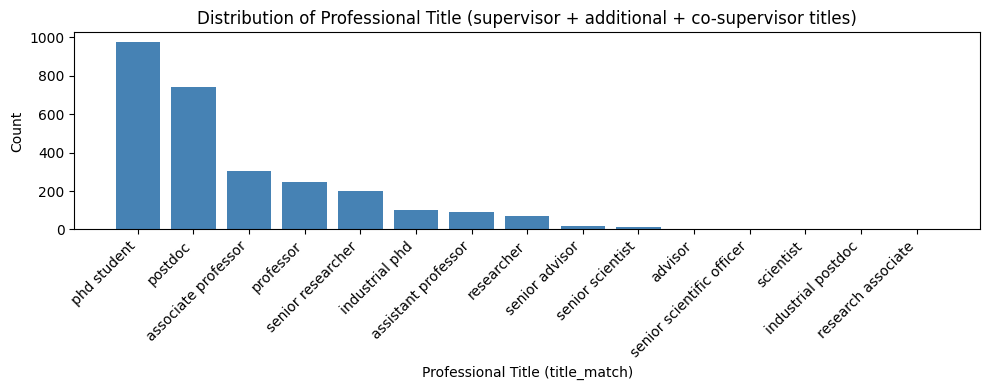


Department distribution:


,dep_match,count,pct
0,DTU Construct,245,8.85
1,DTU Compute,240,8.67
2,DTU Wind,205,7.40
3,DTU Bioengineering,197,7.11
4,DTU Health Tech,194,7.01
5,DTU Electro,189,6.83
6,DTU Sustain,165,5.96
7,DTU Physics,164,5.92
8,DTU Chemical Engineering,154,5.56
9,DTU Food,149,5.38


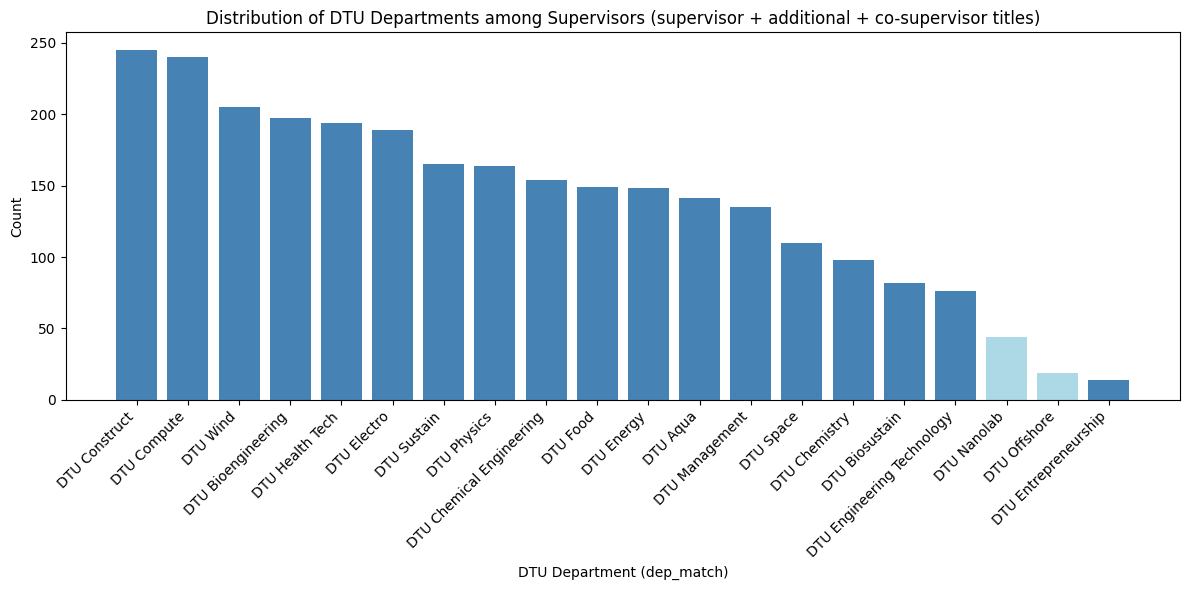

In [41]:

# ==== Imports ====
import matplotlib.pyplot as plt
import pandas as pd


# ==== Loading the data ====


sorting = input("what dataset do you want to load? (1) supervisor titles only, (2) supervisor + additional titles, (3) supervisor + additional + co-supervisor titles: ")

pd.set_option("display.max_colwidth", None)  # Show full text in cells
if sorting == "1":
    orbit_data = pd.read_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_only.csv')
    print(f"Loaded cleaned datset with {len(orbit_data)} rows.")
elif sorting == "2":
    orbit_data = pd.read_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_and_additional.csv')
    print(f"Loaded cleaned datset with {len(orbit_data)} rows.")
elif sorting == "3":
    orbit_data = pd.read_csv('../Data/Orbit_meta/Cleaned/dtu_orbit_persons_supervisors_additional_cosupervisors.csv')
    print(f"Loaded cleaned datset with {len(orbit_data)} rows.")


# ==== Exploring the cleaned dataset ====


# Exploratory analytics on supervisors by professional title and DTU department
# Main columns used: "professional_title" and "dep_match"

# 1) Basic checks
required_cols = ["title_match", "dep_match"]
missing_cols = [c for c in required_cols if c not in orbit_data.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in orbit_data: {missing_cols}")

n_rows = len(orbit_data)
print(f"Rows in orbit_data: {n_rows}")
print(f"Missing title_match: {orbit_data['title_match'].isna().sum()}")
print(f"Missing dep_match: {orbit_data['dep_match'].isna().sum()}")


# ==== Distribution of professional titles ====


# 2) Distribution of professional titles
print("\nProfessional title distribution:")
# 2.1) Table of distribution of professional titles
title_stats = (
    orbit_data["title_match"]
    .value_counts(dropna=False)
    .rename_axis("title_match")
    .reset_index(name="count")
)
title_stats["pct"] = (title_stats["count"] / n_rows * 100).round(2)
display(title_stats)

if sorting == "1":
    title = "Distribution of Professional Title (supervisor titles only)"
elif sorting == "2":
    title = "Distribution of Professional Title (supervisor + additional titles)"
elif sorting == "3":
    title = "Distribution of Professional Title (supervisor + additional + co-supervisor titles)"

# 2.2) Bar chart of distribution of professional titles
plt.figure(figsize=(10, 4))
plt.bar(title_stats["title_match"], title_stats["count"], color="steelblue")
plt.xlabel("Professional Title (title_match)")
plt.ylabel("Count")
plt.title(title)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ==== Distribution of DTU departments ====


# 3) Distribution of DTU departments
print("\nDepartment distribution:")

# 3.1) Table of distribution of departments
dep_stats = (
    orbit_data["dep_match"]
    .value_counts(dropna=False)
    .rename_axis("dep_match")
    .reset_index(name="count")
)
dep_stats["pct"] = (dep_stats["count"] / n_rows * 100).round(2)

display(dep_stats)

if sorting == "1":
    title = "Distribution of DTU Departments among Supervisors (supervisor titles only)"
elif sorting == "2":
    title = "Distribution of DTU Departments among Supervisors (supervisor + additional titles)"
elif sorting == "3":
    title = "Distribution of DTU Departments among Supervisors (supervisor + additional + co-supervisor titles)"

# 3.2) Bar chart of distribution of departments
HIGHLIGHT_DEPS = {"DTU Bright", "DTU Learn for Life", "DTU Nanolab", "DTU Offshore", "DTU Skylab"}
dep_colors = ["lightblue" if dep in HIGHLIGHT_DEPS else "steelblue" for dep in dep_stats["dep_match"]]

plt.figure(figsize=(12, 6))
plt.bar(dep_stats["dep_match"], dep_stats["count"], color=dep_colors)
plt.xlabel("DTU Department (dep_match)")
plt.ylabel("Count")
plt.title(title)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# EVERYTHING EVERYWHERE ALL AT ONCE

In [ ]:
# 4) Title x Department cross table
ct = pd.crosstab(orbit_data["title_match"], orbit_data["dep_match"])
ct_with_total = ct.copy()
ct_with_total["Total"] = ct_with_total.sum(axis=1)

print("\nCross table (counts): title_match x dep_match")
display(ct_with_total.head())
# display(ct_with_total) # unhash for full view

# 5) Normalized views
ct_row_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)   # department mix within each title
ct_col_pct = (ct.div(ct.sum(axis=0), axis=1) * 100).round(1)   # title mix within each department

print("\nRow-normalized cross table (% within each professional_title):")
display(ct_row_pct.head())
#display(ct_row_pct) # unhash for full view

print("\nColumn-normalized cross table (% within each dep_match):")
display(ct_col_pct.head())
#display(ct_col_pct) # unhash for full view

# 6) Most frequent title-department combinations
pair_stats = (
    orbit_data.groupby(["title_match", "dep_match"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
pair_stats["pct_of_all"] = (pair_stats["count"] / n_rows * 100).round(2)

print("\nTop 20 title-department pairs:")
display(pair_stats.head(20))

# 7) Diversity metrics
# Number of unique titles per department + dominant title share
dep_diversity = (
    orbit_data.groupby("dep_match")["title_match"]
    .nunique()
    .rename("n_unique_titles")
    .reset_index()
)

dep_top_title = (
    orbit_data.groupby(["dep_match", "title_match"])
    .size()
    .reset_index(name="count")
    .sort_values(["dep_match", "count"], ascending=[True, False])
    .drop_duplicates("dep_match")
    .rename(columns={"title_match": "top_title", "count": "top_title_count"})
)

dep_sizes = (
    orbit_data.groupby("dep_match")
    .size()
    .rename("department_total")
    .reset_index()
)

dep_summary = dep_sizes.merge(dep_diversity, on="dep_match").merge(dep_top_title, on="dep_match")
dep_summary["top_title_share_pct"] = (dep_summary["top_title_count"] / dep_summary["department_total"] * 100).round(2)
dep_summary = dep_summary.sort_values("department_total", ascending=False)

print("\nDepartment-level diversity and dominant title:")
display(dep_summary)

# Number of unique departments per title
title_spread = (
    orbit_data.groupby("title_match")["dep_match"]
    .nunique()
    .rename("n_unique_departments")
    .reset_index()
    .sort_values("n_unique_departments", ascending=False)
)

print("\nTitle spread across departments:")
display(title_spread.head())
# display(title_spread) # unhash for full view